# PROYECTO M3

## PAQUETERÍAS

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("singhnproud77/eastwestairlines-heirarchical-clustering")

print("Path to dataset files:", path)

100%|██████████| 53.9k/53.9k [00:00<00:00, 2.60MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/singhnproud77/eastwestairlines-heirarchical-clustering/versions/1


In [3]:
def calculate_kn_distance(X, k=2):
    # Definimos la función para calcular la distancia al k-ésimo vecino más cercano
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, _ = nbrs.kneighbors(X)
    return distances[:, k-1]

def plot_kn_distance(X, k):
    # Definimos la función para trazar la curva de la distancia al k-ésimo vecino más cercano
    distances = calculate_kn_distance(X, k=k)
    distances = np.sort(distances, axis=0)

    # Crear el gráfico de codo
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=list(range(1, len(distances)+1)), y=distances,
                                mode='lines+markers',
                                name='Curva de distancia k'))
    fig.update_layout(title='Curva de distancia k',
                        xaxis_title='Puntos Ordenados por Distancia',
                        yaxis_title=f'Distancia al {k}-ésimo vecino más próximo',
                        showlegend=False)
    fig.show()

In [4]:
for filename in os.listdir(path):
    print(filename)

EastWestAirlines.csv


In [5]:
df = pd.read_csv(os.path.join(path, "EastWestAirlines.csv"))

## EDA

In [6]:
df.columns

Index(['ID', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award              3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


### Balance

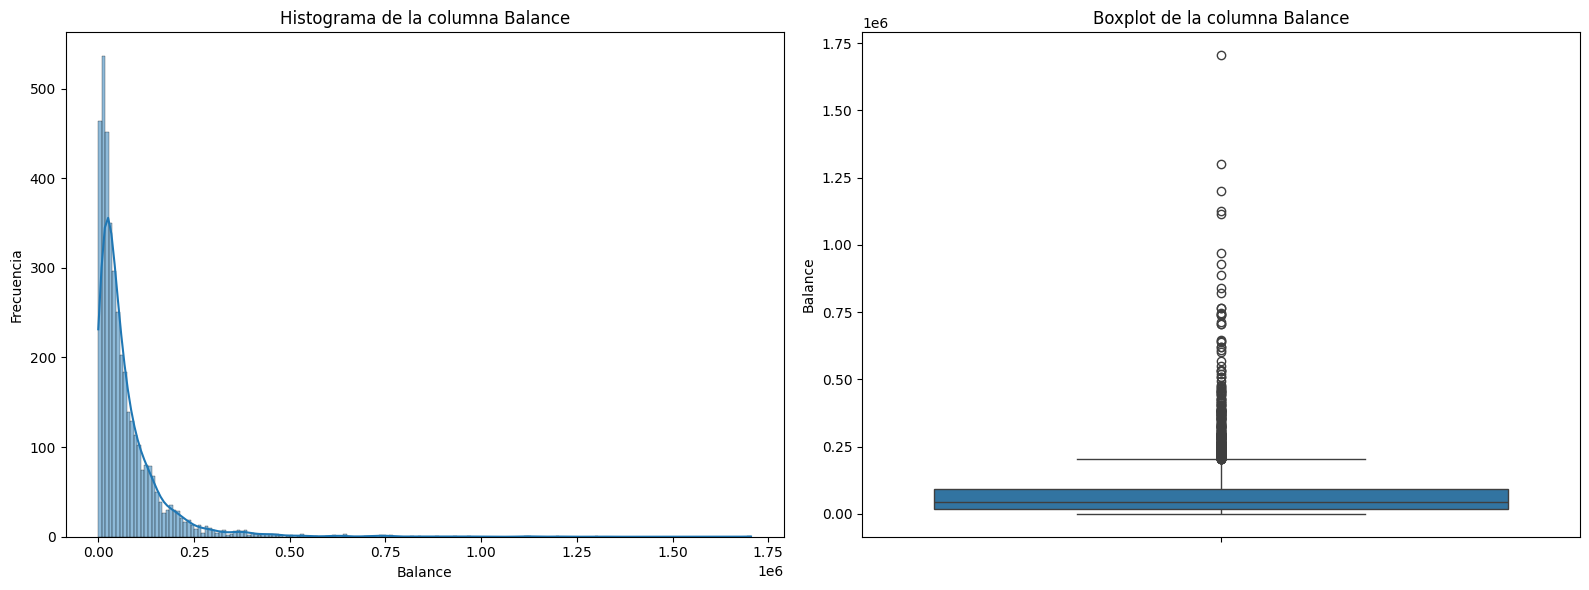

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Balance'], kde=True, ax=axes[0])
axes[0].set_title('Histograma de la columna Balance')
axes[0].set_xlabel('Balance')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=df['Balance'], ax=axes[1])
axes[1].set_title('Boxplot de la columna Balance')
axes[1].set_ylabel('Balance')

plt.tight_layout()
plt.show()

### Número de Vuelos en los últimos 12 meses

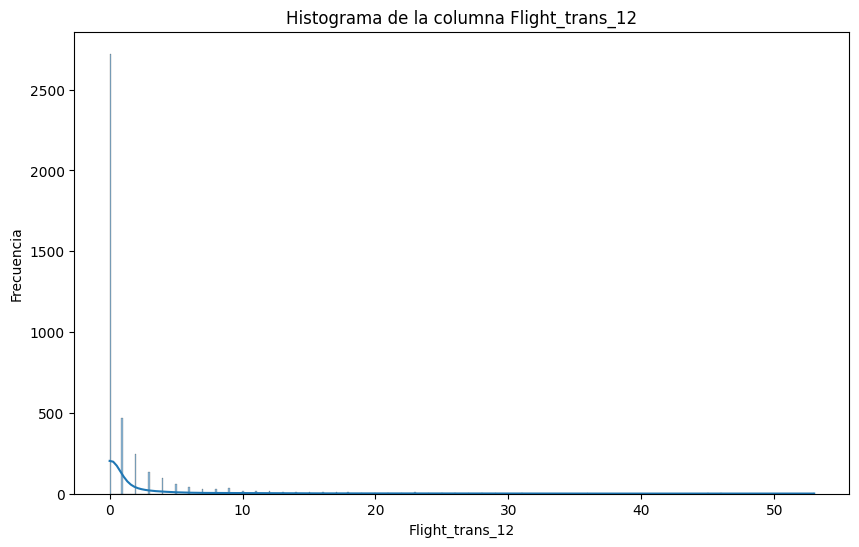

In [9]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Flight_trans_12'], kde=True)
plt.title('Histograma de la columna Flight_trans_12')
plt.xlabel('Flight_trans_12')
plt.ylabel('Frecuencia')
plt.show()

### Bonus miles( Millas ganadas con acciones o actividades que no sean vuelos)

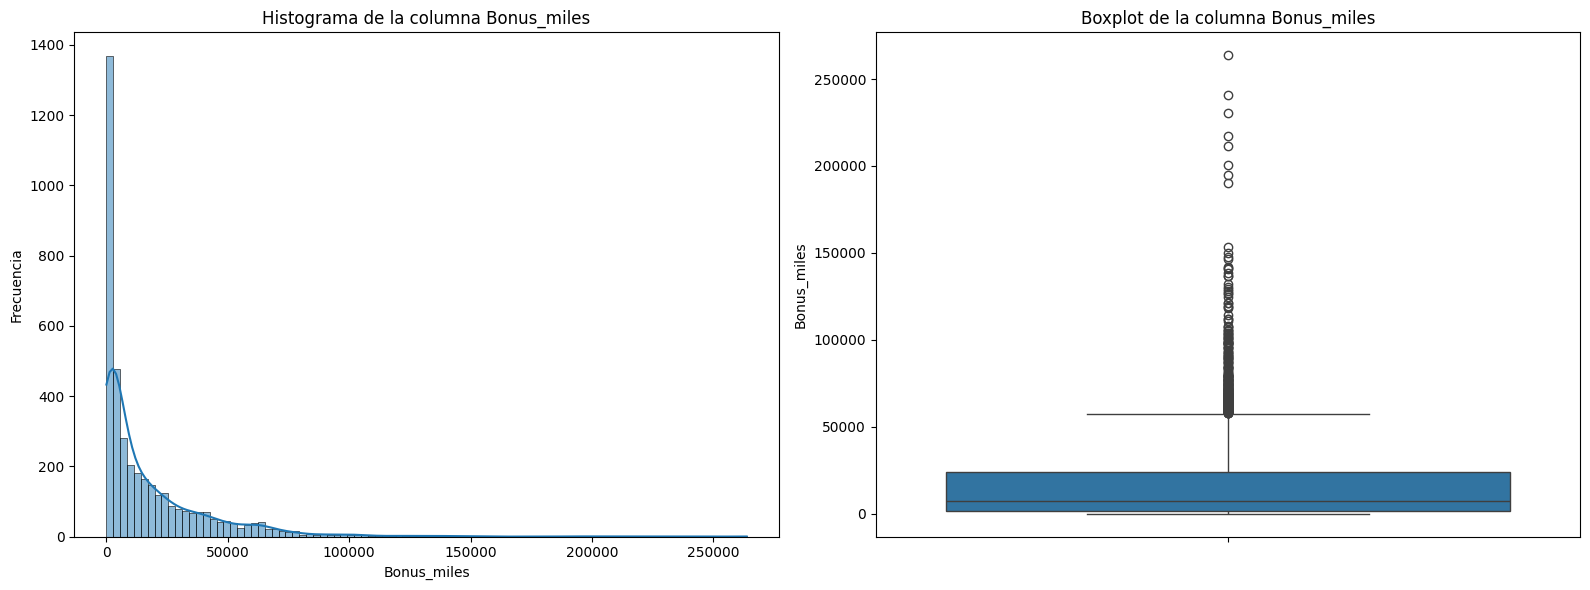

In [10]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Bonus_miles'], kde=True, ax=axes[0])
axes[0].set_title('Histograma de la columna Bonus_miles')
axes[0].set_xlabel('Bonus_miles')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=df['Bonus_miles'], ax=axes[1])
axes[1].set_title('Boxplot de la columna Bonus_miles')
axes[1].set_ylabel('Bonus_miles')

plt.tight_layout()
plt.show()

### Tarjetas de Crédito

Estas tres variables corresponden a las diferentes tarjetas de crédito de las cuales se tienen registro, dentro de cada tarjeta de crédito hay distintos niveles en donde se aprecia de cierta manera el valor financiero d ecada usuario

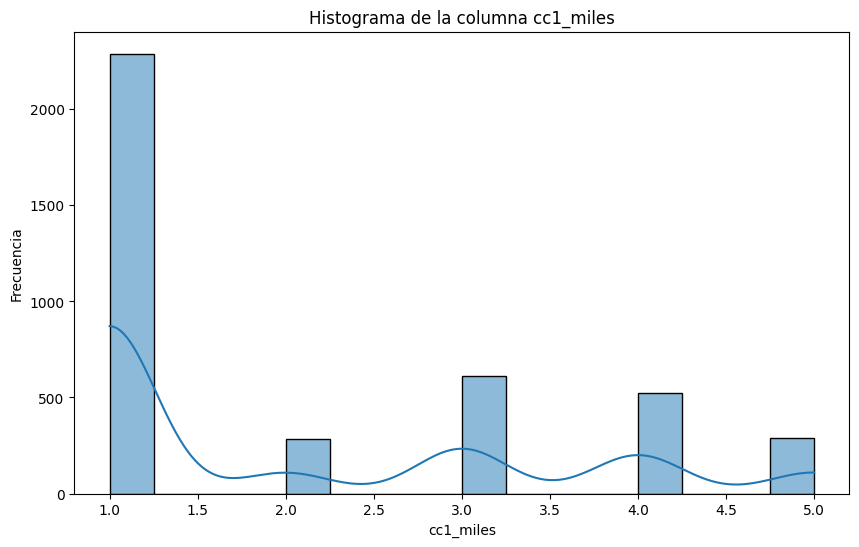

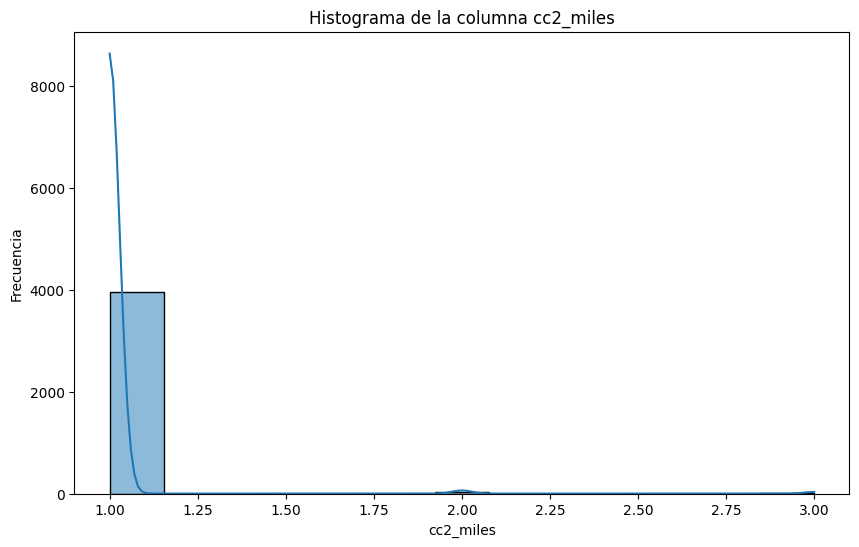

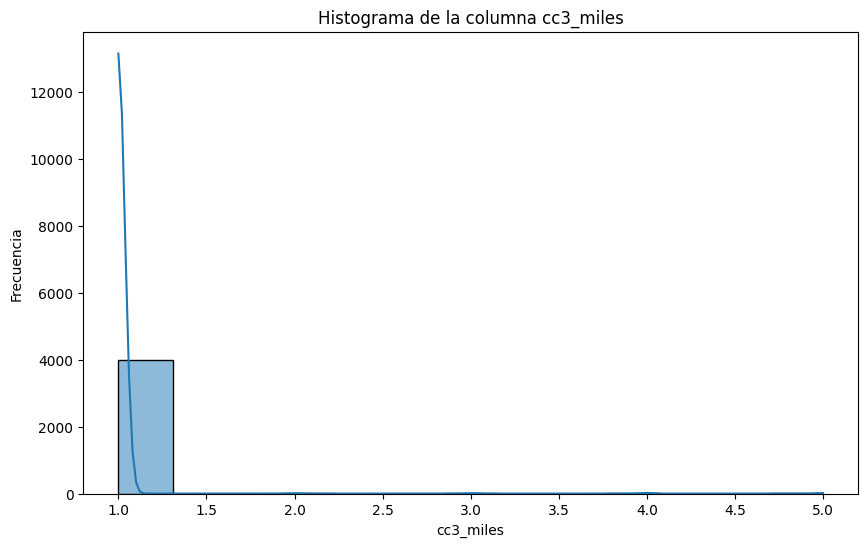

In [11]:


columns_to_plot = ['cc1_miles', 'cc2_miles', 'cc3_miles']

for column in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True)
    plt.title(f'Histograma de la columna {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

In [12]:
df['Days_since_enroll'].max()

8296

In [13]:
df['Days_since_enroll'].min()

2

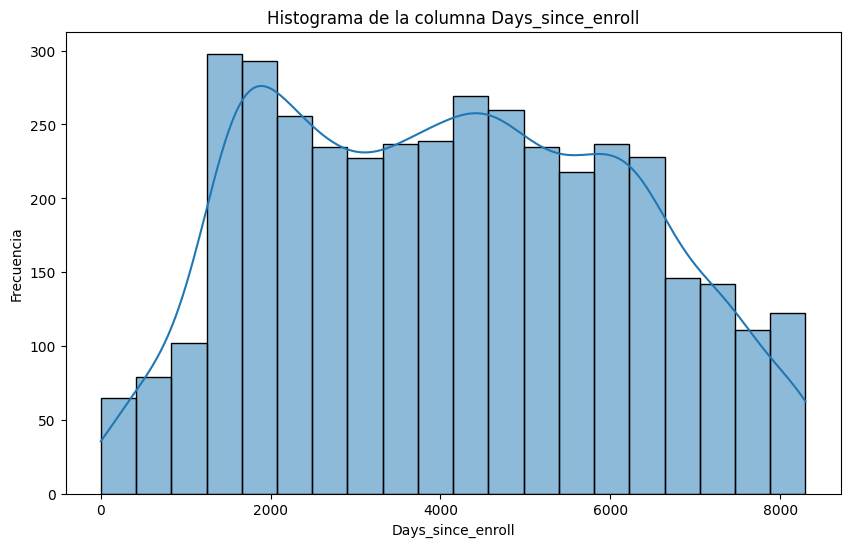

In [14]:


plt.figure(figsize=(10, 6))
sns.histplot(df['Days_since_enroll'], kde=True)
plt.title('Histograma de la columna Days_since_enroll')
plt.xlabel('Days_since_enroll')
plt.ylabel('Frecuencia')
plt.show()

## DATA WRANGLING

Se va a crear una variable para ver las millas totales, sumando las millas acumuladas en cada una de las tarjetas de crédito, para saber las millas totales por cliente o usuario

In [15]:
df['total_miles'] = df['cc1_miles'] + df['cc2_miles'] + df['cc3_miles']

Se va a crear una variable de "performance" para saber su balance en el tiempo

In [16]:
df['flight_performance']= df['Balance'] / df['Days_since_enroll']

Esta última variable es para saber las millas promedio por vuelo

In [17]:
df["millas_promedio"]= df['Flight_miles_12mo'] / df['Flight_trans_12']

In [18]:
df['millas_promedio'] = df['millas_promedio'].fillna(0)

### Transformación y Escalado de los datos

 Debido a que en el análisis exploratorio se vió una disparidad en la información y existen múltiples outliers en muchas de las variables, se va a optar por aplicar transformación logarítmica a las variables y minimizar el efecto que estos puedan tener en los modelos de clusterización

In [19]:
var_continuas = ['Balance', 'Bonus_miles', 'Days_since_enroll', 'Flight_miles_12mo', 'Flight_trans_12', 'Qual_miles', 'total_miles', 'flight_performance', 'millas_promedio', 'Bonus_trans']

In [20]:
df_transformed = df.copy()
for col in var_continuas:
    df_transformed[col] = np.log1p(df_transformed[col])

# Impute NaN values in 'millas_promedio' with 0
df_transformed['millas_promedio'].fillna(0, inplace=True)

display(df_transformed.head())

/tmp/ipython-input-882073766.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_transformed['millas_promedio'].fillna(0, inplace=True)


,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,total_miles,flight_performance,millas_promedio
0,1,10.245089,0.0,1,1,1,5.164786,0.693147,0.000000,0.000000,8.853808,0,1.386294,1.613515,0.000000
1,2,9.865007,0.0,1,1,1,5.375278,1.098612,0.000000,0.000000,8.849227,0,1.386294,1.324889,0.000000
2,3,10.629949,0.0,1,1,1,8.324579,1.609438,0.000000,0.000000,8.858653,0,1.386294,1.928496,0.000000
3,4,9.600827,0.0,1,1,1,6.216606,0.693147,0.000000,0.000000,8.846929,0,1.386294,1.139572,0.000000
4,5,11.490199,0.0,4,1,1,10.675931,3.295837,7.639161,1.609438,8.844481,1,1.945910,2.714394,6.254309


In [21]:


variables_escaladas = df_transformed.columns.tolist()
variables_escaladas.remove('ID')

scaler = StandardScaler()
df_escalado = scaler.fit_transform(df_transformed[variables_escaladas])

# Convert the scaled data back to a DataFrame for easier handling
df_escalado = pd.DataFrame(df_escalado, columns=variables_escaladas)

display(df_escalado.head())

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,total_miles,flight_performance,millas_promedio
0,-0.240588,-0.243383,-0.769578,-0.098242,-0.062767,-0.829165,-1.350586,-0.669104,-0.576530,0.991086,-0.766919,-0.808425,-0.948906,-0.677077
1,-0.538514,-0.243383,-0.769578,-0.098242,-0.062767,-0.764962,-0.967138,-0.669104,-0.576530,0.984733,-0.766919,-0.808425,-1.232953,-0.677077
2,0.061081,-0.243383,-0.769578,-0.098242,-0.062767,0.134622,-0.484051,-0.669104,-0.576530,0.997804,-0.766919,-0.808425,-0.638922,-0.677077
3,-0.745589,-0.243383,-0.769578,-0.098242,-0.062767,-0.508343,-1.350586,-0.669104,-0.576530,0.981545,-0.766919,-0.808425,-1.415330,-0.677077
4,0.735382,-0.243383,1.409471,-0.098242,-0.062767,0.851822,1.110774,1.760457,1.575216,0.978150,1.303918,1.387109,0.134507,1.671198


In [22]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  3999 non-null   int64  
 1   Balance             3999 non-null   float64
 2   Qual_miles          3999 non-null   float64
 3   cc1_miles           3999 non-null   int64  
 4   cc2_miles           3999 non-null   int64  
 5   cc3_miles           3999 non-null   int64  
 6   Bonus_miles         3999 non-null   float64
 7   Bonus_trans         3999 non-null   float64
 8   Flight_miles_12mo   3999 non-null   float64
 9   Flight_trans_12     3999 non-null   float64
 10  Days_since_enroll   3999 non-null   float64
 11  Award               3999 non-null   int64  
 12  total_miles         3999 non-null   float64
 13  flight_performance  3999 non-null   float64
 14  millas_promedio     3999 non-null   float64
dtypes: float64(10), int64(5)
memory usage: 468.8 KB


## Modelos

In [23]:

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(df_escalado)

df_tsne = pd.DataFrame(tsne_results, columns=['tsne_component_1', 'tsne_component_2'])

display(df_tsne.head())

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


,tsne_component_1,tsne_component_2
0,-2.152103,0.598830
1,-2.214534,0.534542
2,-3.555839,-3.028723
3,-2.205944,0.723959
4,10.367460,0.667686


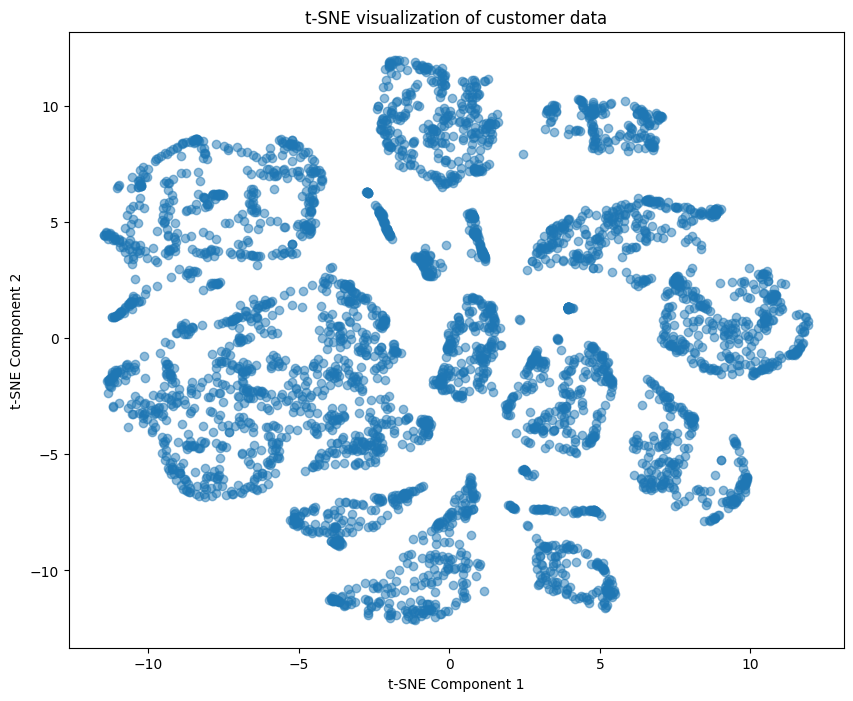

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(df_tsne['tsne_component_1'], df_tsne['tsne_component_2'], alpha=0.5)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE visualization of customer data')
plt.show()

###DBSCAN


In [25]:
df_escalado.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award', 'total_miles', 'flight_performance',
       'millas_promedio'],
      dtype='object')

In [26]:
# Preparamos las características relevantes
X = df_escalado[['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award', 'total_miles', 'flight_performance',
       'millas_promedio']]
#X_scaled = StandardScaler().fit_transform(X)

plot_kn_distance(X, 24)

In [27]:
# Aplicamos DBSCAN
dbs = DBSCAN(eps=1.6, min_samples=35).fit(X)
labels = dbs.labels_

df['Cluster'] = labels



In [28]:
X_array = X.values if hasattr(X, 'values') else X

# --- PASO 2: REDUCCIÓN DE DIMENSIONES PARA VISUALIZACIÓN ---
# Aplicamos PCA a los datos escalados (X) para obtener 2 componentes
pca = PCA(n_components=2)
components = pca.fit_transform(X_array)

# Creamos un DataFrame para la visualización
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].astype(str) # Usamos las etiquetas del DBSCAN

# --- PASO 3: GRÁFICO DE DISPERSIÓN 2D ---
fig = px.scatter(pca_df,
                 x='PC1',
                 y='PC2',
                 color='Cluster',
                 title='DBSCAN Clustering (Proyección PCA)',
                 labels={'color': 'Cluster'},
                 color_discrete_sequence=px.colors.qualitative.Plotly,
                 opacity=0.8)

fig.show()

# Opcional: Ejecutar para ver la distribución del clúster después de DBSCAN
print("\nDistribución del tamaño de los clústeres:")
print(df['Cluster'].value_counts())


Distribución del tamaño de los clústeres:
Cluster
 0    1866
 2     660
 1     565
 3     478
-1     430
Name: count, dtype: int64


In [29]:
# X_scaled es tu matriz de datos transformados y escalados
X_array = X.values if hasattr(X, 'values') else X

# Aplicamos t-SNE a los datos escalados para obtener 2 componentes
# Nota: t-SNE es computacionalmente intensivo, así que puede tardar más que PCA
tsne = TSNE(n_components=2, random_state=42)
components = tsne.fit_transform(X_array)

# Creamos un DataFrame para la visualización
tsne_df = pd.DataFrame(data=components, columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['Cluster'] = df['Cluster'].astype(str) # Usamos las etiquetas de DBSCAN (el resultado del clustering)

In [30]:
fig = px.scatter(tsne_df,
                 x='t-SNE Component 1',
                 y='t-SNE Component 2',
                 color='Cluster',
                 title='DBSCAN Clustering (Visualización con t-SNE)',
                 labels={'color': 'Cluster'},
                 color_discrete_sequence=px.colors.qualitative.Plotly,
                 opacity=0.8)
fig.show()

## Perfilamiento


In [31]:
df['Cluster'] = labels

# ===================================================================
# PASO 2: PERFILAMIENTO Y CÁLCULO DE ESTADÍSTICAS
# ===================================================================

# Variables clave para el perfil (usamos las originales para la interpretabilidad)
VARIABLES_CLAVE = [
    'Balance',
    'cc1_miles', # Nivel de tarjeta (1-5)
    'Bonus_miles',
    'Flight_trans_12', # Frecuencia de vuelo
    'Days_since_enroll', # Antigüedad
    'millas_promedio' # Tu variable calculada
]


In [32]:
# 1. Calculamos la media para cada cluster (usamos la media para una visión rápida)
perfil_cluster = df.groupby('Cluster')[VARIABLES_CLAVE].mean().round(2)

# 2. Obtenemos el tamaño del cluster para el contexto
tamaño_cluster = df['Cluster'].value_counts().rename('Tamaño')

# Concatenamos el tamaño al perfil para una visión completa
perfil_final = pd.concat([tamaño_cluster, perfil_cluster], axis=1)

print("\n--- Perfil Final de los Clústeres (Medias de Variables Originales) ---")
print(perfil_final)


--- Perfil Final de los Clústeres (Medias de Variables Originales) ---
         Tamaño    Balance  cc1_miles  Bonus_miles  Flight_trans_12  \
Cluster                                                               
 0         1866   52713.08       1.69      9423.13             0.00   
 2          660   68633.23       2.82     26080.92             0.00   
 1          565  111668.00       2.72     32631.89             4.10   
 3          478   87183.22       1.82     12541.60             2.73   
-1          430  106756.22       1.89     21705.51             4.36   

         Days_since_enroll  millas_promedio  
Cluster                                      
 0                 3838.38             0.00  
 2                 4596.55             0.00  
 1                 4678.95           356.14  
 3                 4123.25           374.96  
-1                 3859.21           181.23  


In [33]:
perfil_final

,Tamaño,Balance,cc1_miles,Bonus_miles,Flight_trans_12,Days_since_enroll,millas_promedio
Cluster,,,,,,,
0,1866,52713.08,1.69,9423.13,0.00,3838.38,0.00
2,660,68633.23,2.82,26080.92,0.00,4596.55,0.00
1,565,111668.00,2.72,32631.89,4.10,4678.95,356.14
3,478,87183.22,1.82,12541.60,2.73,4123.25,374.96
-1,430,106756.22,1.89,21705.51,4.36,3859.21,181.23


In [34]:
import pickle

# Save the trained DBSCAN model
with open('dbscan_model.pkl', 'wb') as f:
    pickle.dump(dbs, f)

print("DBSCAN model saved to dbscan_model.pkl")

DBSCAN model saved to dbscan_model.pkl
